# Fase 5 — Reporte automatizado de partido

Módulo 12 del temario. La idea es combinar en una sola figura (o PDF) varias
de las visualizaciones ya construidas, para poder generarlas en minutos tras
cada partido y compartirlas con cuerpo técnico.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

events = pd.read_pickle("../data/processed/events_ejemplo.pkl")
equipo = events["team"].dropna().unique()[0]

## Figura combinada: shot map + heat map + xG acumulado

Usamos `plt.subplots` con 3 paneles. Reutiliza la lógica de
`02_visualizacion_equipo.ipynb` para cada panel.

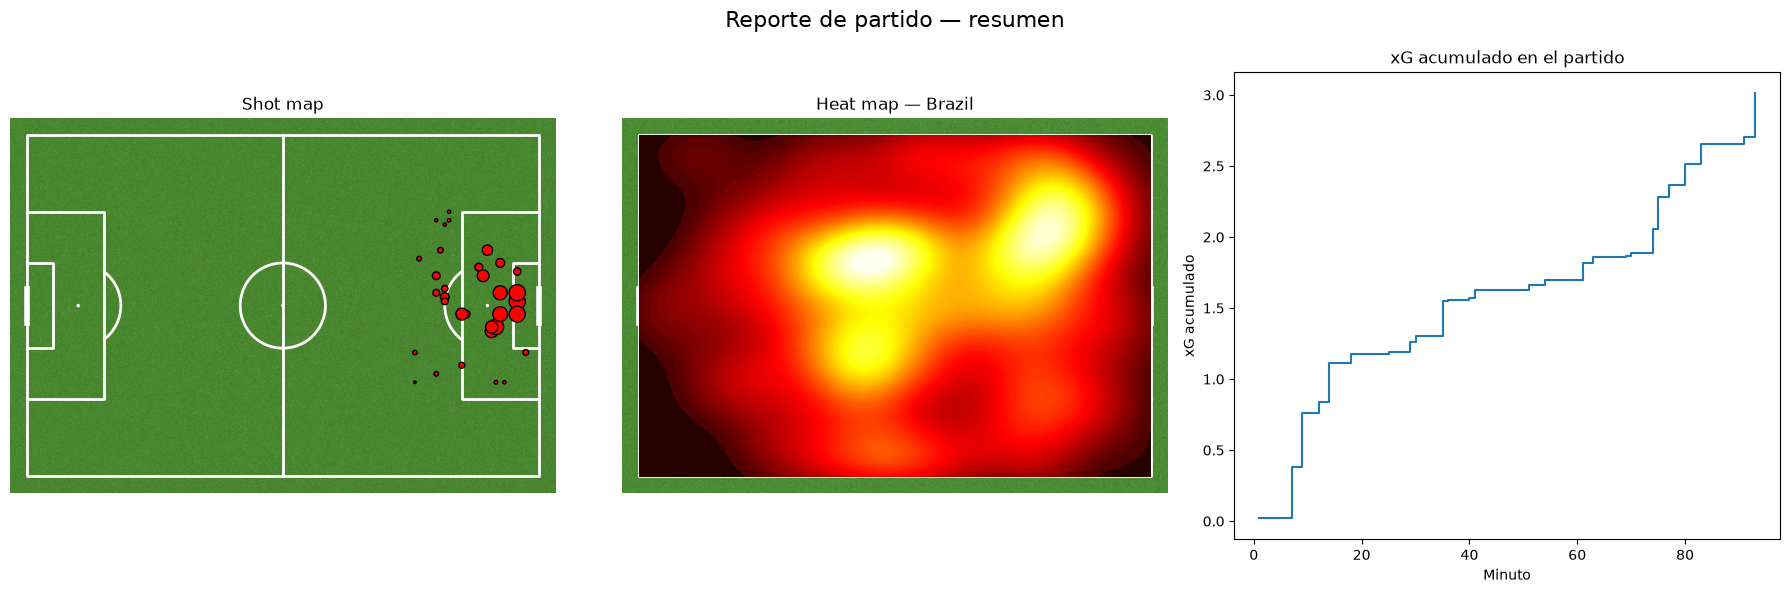

In [15]:
shots = events[events["type"] == "Shot"].copy()
shots[["x", "y"]] = pd.DataFrame(shots["location"].tolist(), index=shots.index)

acciones_equipo = events[events["team"] == equipo].dropna(subset=["location"]).copy()
acciones_equipo[["x", "y"]] = pd.DataFrame(acciones_equipo["location"].tolist(), index=acciones_equipo.index)

fig = plt.figure(figsize=(18, 6))

# Panel 1: shot map
pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white")
ax1 = fig.add_subplot(1, 3, 1)
pitch.draw(ax=ax1)
pitch.scatter(shots.x, shots.y, s=shots["shot_statsbomb_xg"] * 500, color="red", edgecolors="black", ax=ax1)
ax1.set_title("Shot map")

# Panel 2: heat map de equipo
ax2 = fig.add_subplot(1, 3, 2)
pitch.draw(ax=ax2)
pitch.kdeplot(acciones_equipo.x, acciones_equipo.y, ax=ax2, fill=True, levels=100, cmap="hot", thresh=0)
ax2.set_title(f"Heat map — {equipo}")

# Panel 3: xG acumulado en el tiempo
ax3 = fig.add_subplot(1, 3, 3)
shots_ordenados = shots.sort_values("minute")
shots_ordenados["xg_acumulado"] = shots_ordenados["shot_statsbomb_xg"].cumsum()
ax3.step(shots_ordenados["minute"], shots_ordenados["xg_acumulado"], where="post")
ax3.set_xlabel("Minuto")
ax3.set_ylabel("xG acumulado")
ax3.set_title("xG acumulado en el partido")

fig.suptitle("Reporte de partido — resumen", fontsize=16)
fig.tight_layout()

## Exportar a PDF

In [16]:
fig.savefig("../output/figures/reporte_partido_ejemplo.pdf")
print("Reporte guardado en output/figures/reporte_partido_ejemplo.pdf")

Reporte guardado en output/figures/reporte_partido_ejemplo.pdf


## Idea para automatizar de verdad

Envolver todo lo anterior en una función `generar_reporte(match_id)` que:
1. descarga eventos con `sb.events(match_id)`,
2. genera la figura de 3 paneles,
3. guarda el PDF con el nombre de los equipos y la fecha.

Así, procesar un partido nuevo es una sola llamada de función.

Siguiente notebook: `06_scouting_percentiles_similaridad.ipynb` (anexo).